Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

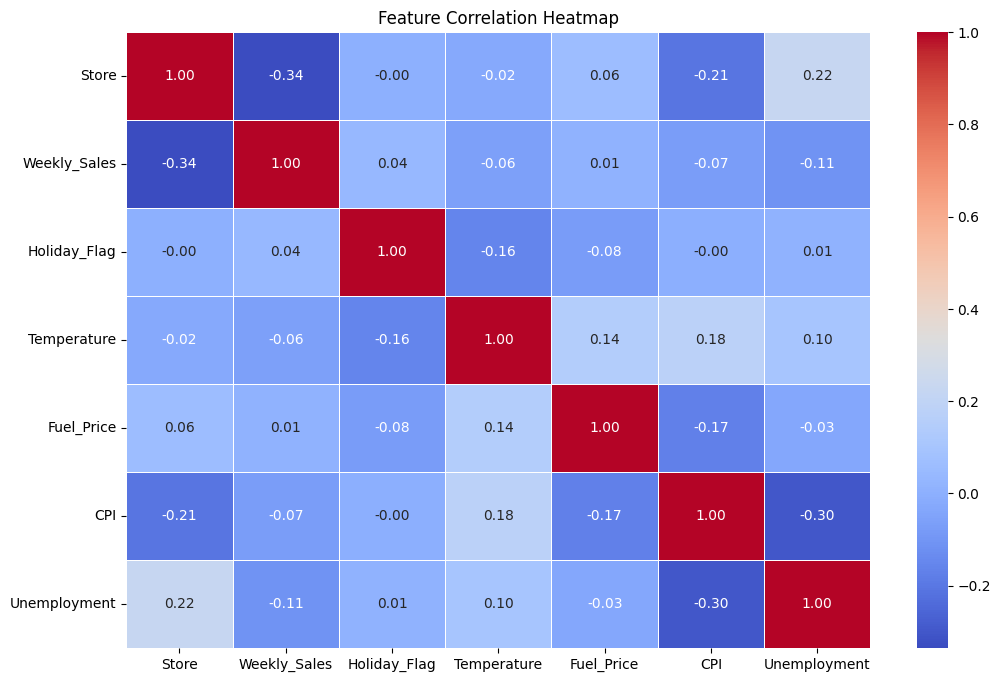

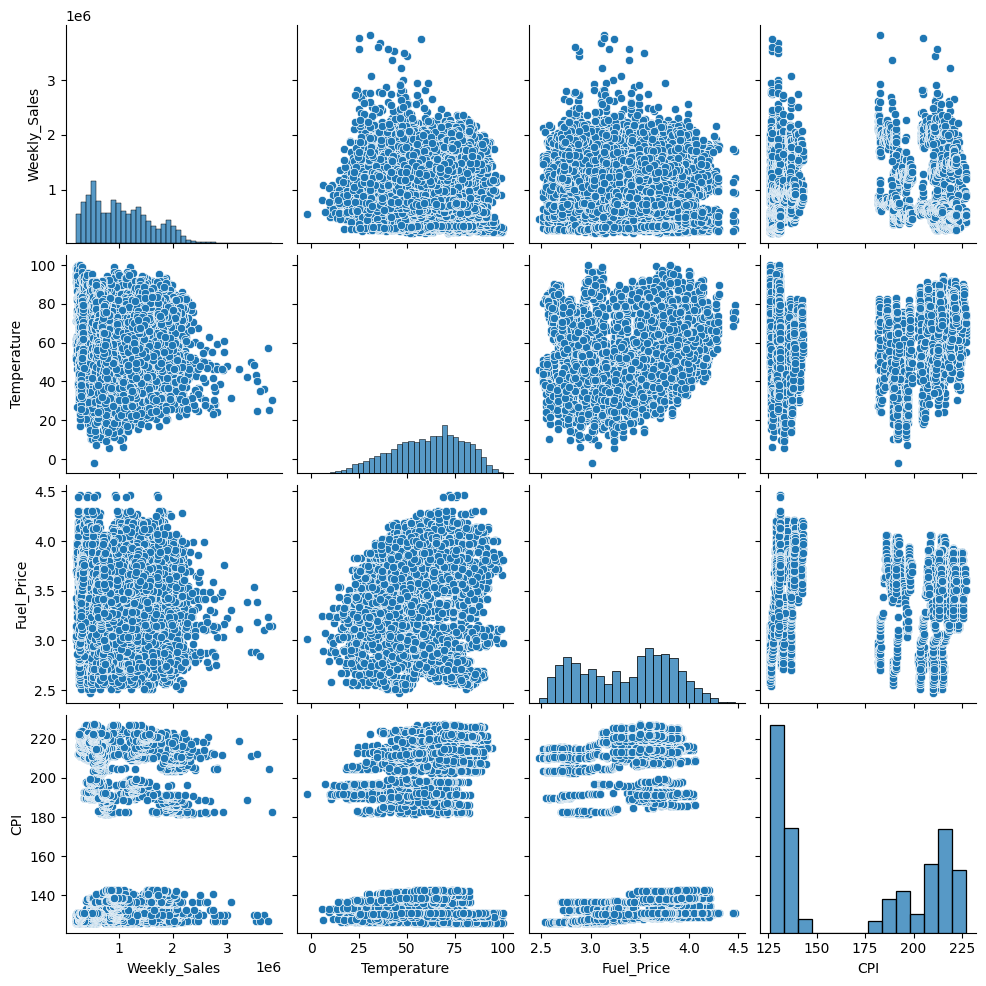

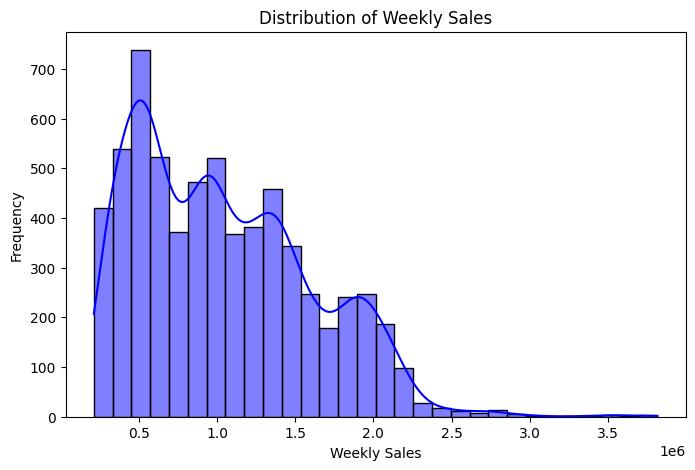

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairplot for key variables
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI']])
plt.show()

# Distribution of target variable (Weekly_Sales)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales"])
y = df["Weekly_Sales"]

# If Date exists, remove it or convert it before training
X = X.drop(columns=["Date"])

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1481
RMSE: 523884.7405


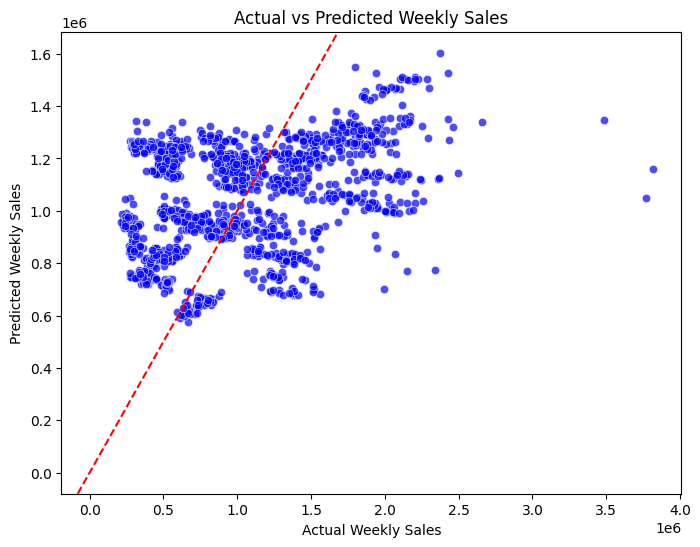

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")

# Perfect prediction reference line (y = x)
plt.axline((0, 0), slope=1, color='red', linestyle='--')

plt.show()

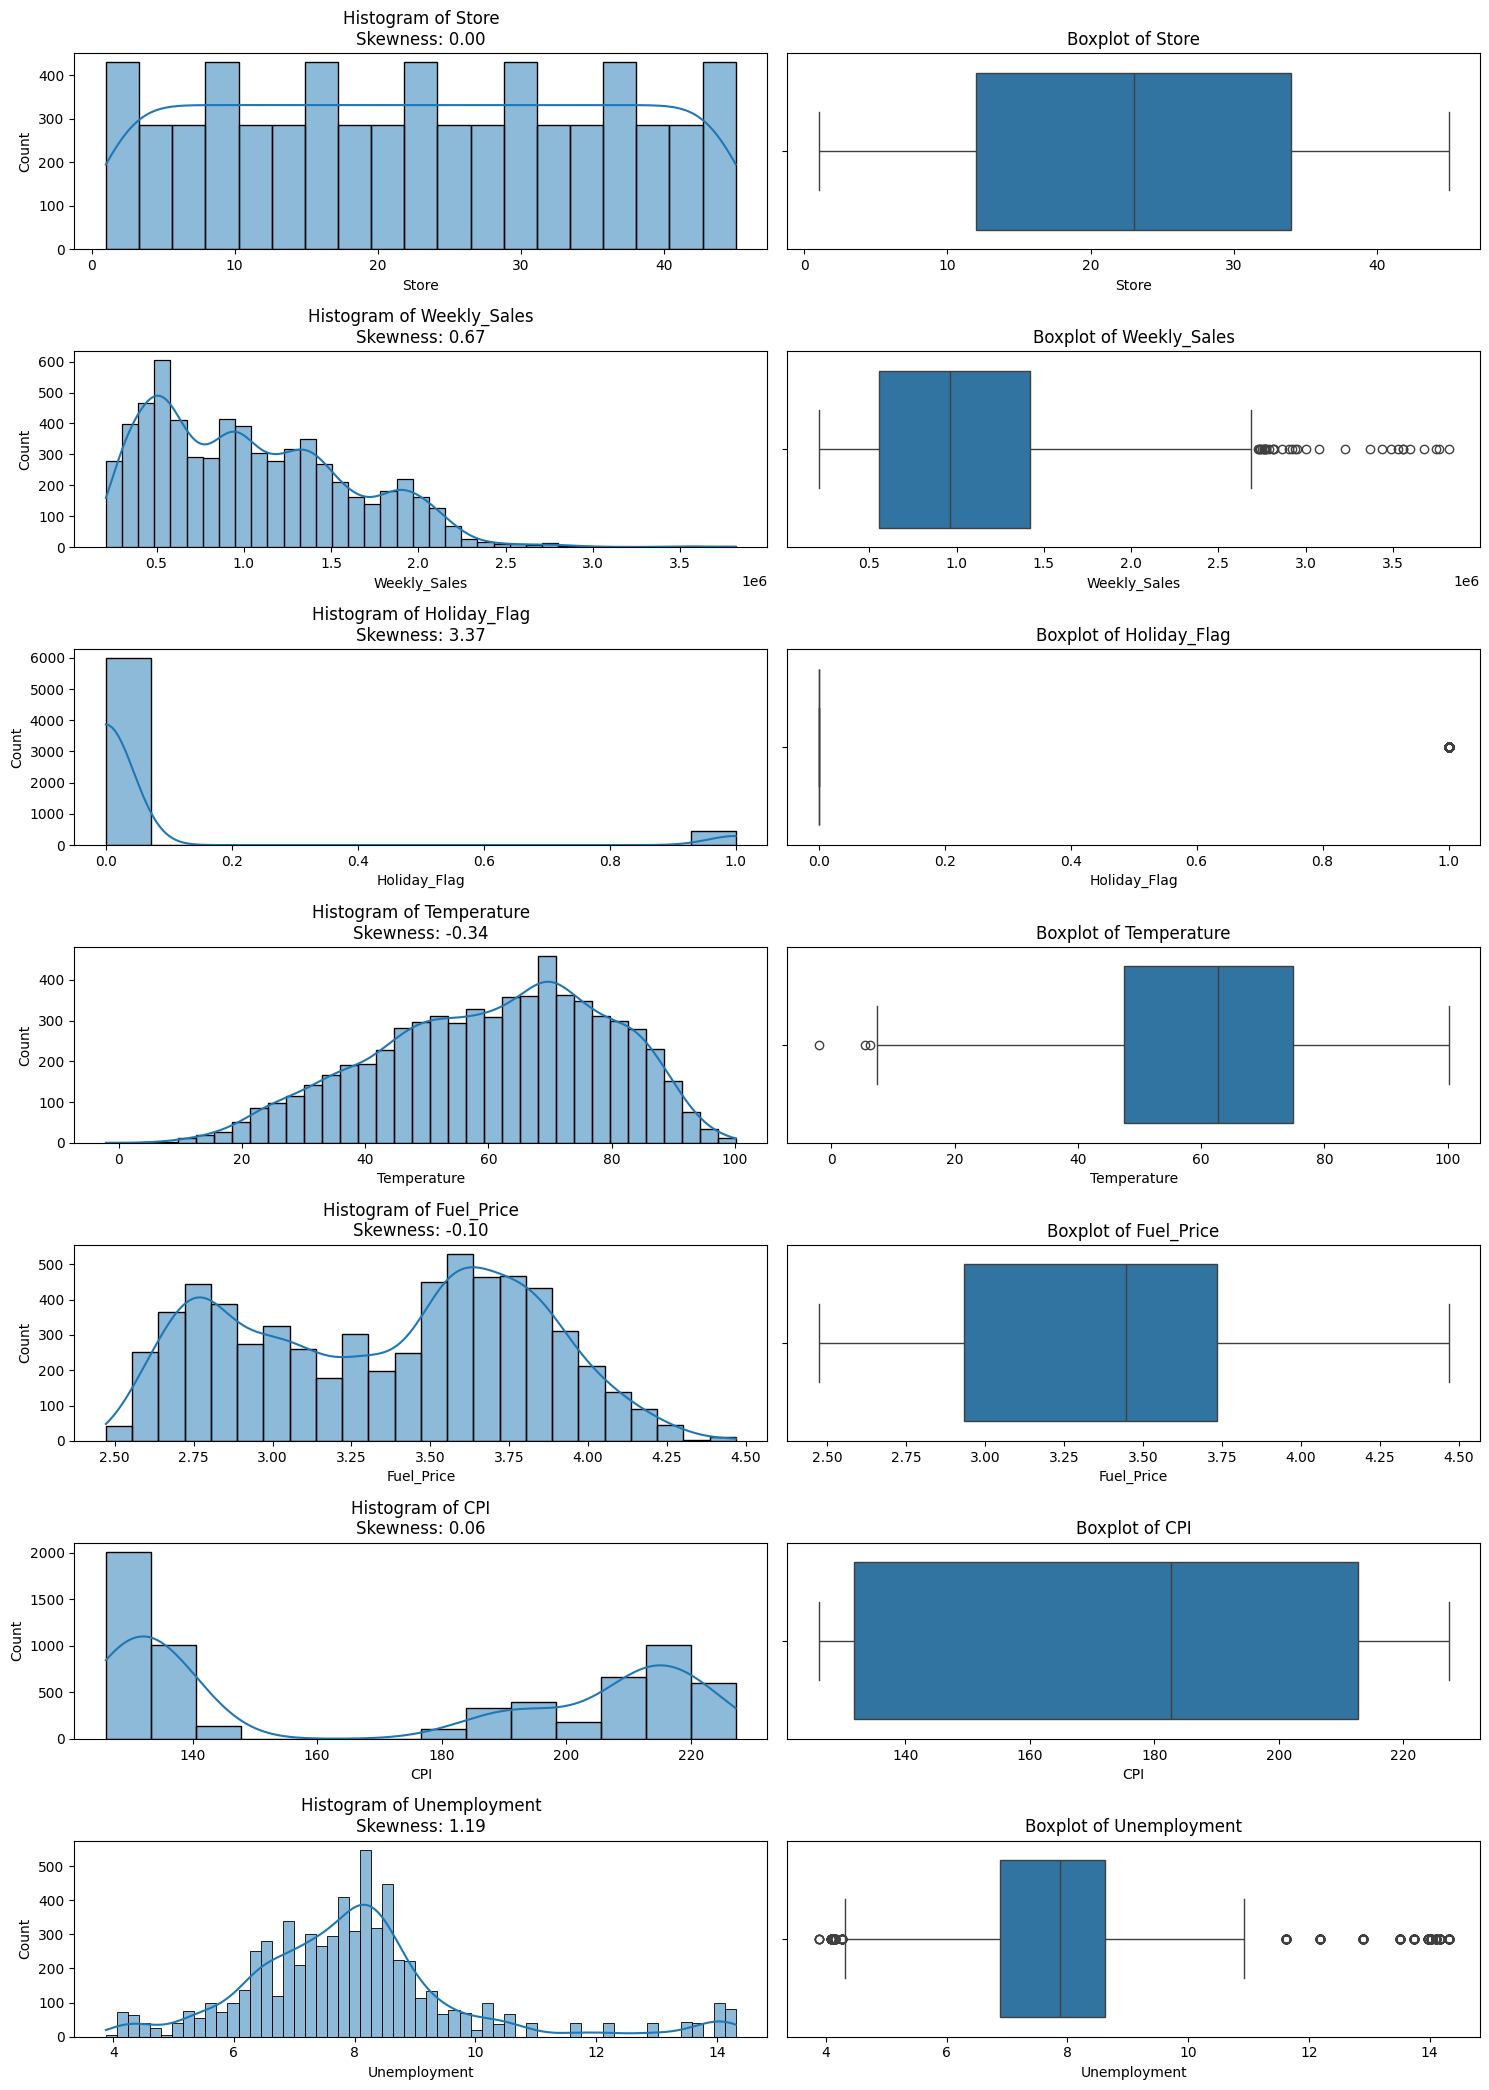

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Calculate skewness
skewness = numeric_df.skew()

# Plot histograms and boxplots
num_cols = len(numeric_df.columns)
plt.figure(figsize=(15, num_cols * 3))

for i, col in enumerate(numeric_df.columns):
    # Histogram
    plt.subplot(num_cols, 2, 2 * i + 1)
    sns.histplot(numeric_df[col], kde=True)
    plt.title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')

    # Boxplot
    plt.subplot(num_cols, 2, 2 * i + 2)
    sns.boxplot(x=numeric_df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Find highly skewed columns
skewed_cols = numeric_df.skew().abs()

highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index

print("Highly Skewed Columns:\n", highly_skewed)
print("Negatively Skewed Columns:\n", negatively_skewed)

# Apply log transformation
df[highly_skewed] = df[highly_skewed].apply(lambda x: np.log1p(x))

Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

# Apply transformation only to numeric columns identified earlier
df[negatively_skewed] = pt.fit_transform(df[negatively_skewed])

# Display skewness of numeric columns only
print(df.select_dtypes(include='number').skew())

Store          -0.228157
Weekly_Sales   -0.049912
Holiday_Flag    3.373499
Temperature    -0.141684
Fuel_Price     -0.055815
CPI             0.010477
Unemployment    0.226991
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales", "Date"])
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1270
RMSE: 0.9464


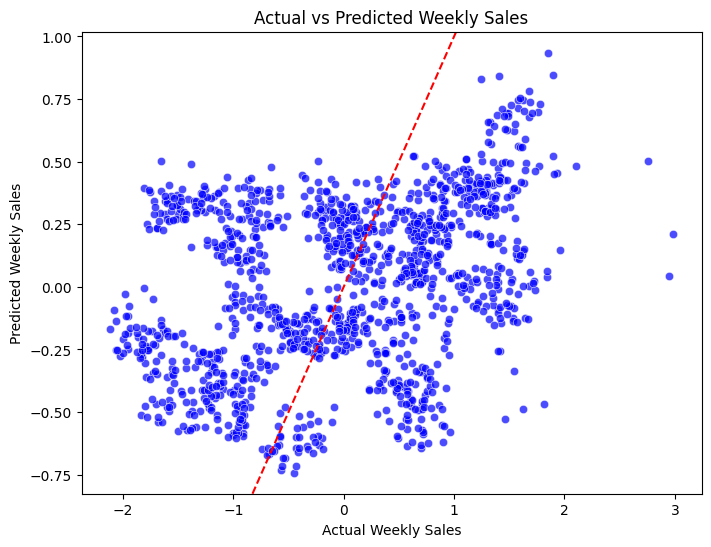

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")

# Perfect prediction reference line (y = x)
plt.axline((0, 0), slope=1, color='red', linestyle='--')

plt.show()